<a href="https://colab.research.google.com/github/jeffwongqy/Uniform-Singapore-Energy-Price-2025/blob/main/ARIMA%2BGARCH%2BBiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install arch

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)

In [ ]:
# load the 2025 USEP dataset from Google Drive
filepath = "/content/drive/MyDrive/Singapore Forecasting Electricity Price/usep_data_2025.xlsx"
# read the Excel file into a pandas dataframe for preprocessing and modelling
usep_df = pd.read_excel(filepath)
# display the first 5 rows to verify the data structure and columns
usep_df.head()

,DATE,USEP,DEMAND,SOLAR
0,2025-01-01,93.600833,5930.052583,158.514792
1,2025-01-02,87.035833,6358.067917,162.426042
2,2025-01-03,105.036667,6407.756771,174.522083
3,2025-01-04,111.137083,6158.840583,177.016875
4,2025-01-05,99.658542,5989.193917,176.524375


# **ARIMA**

In [ ]:
# create a stationary time series by calculating the first-order difference
usep_diff = usep_df['USEP'].diff().dropna()

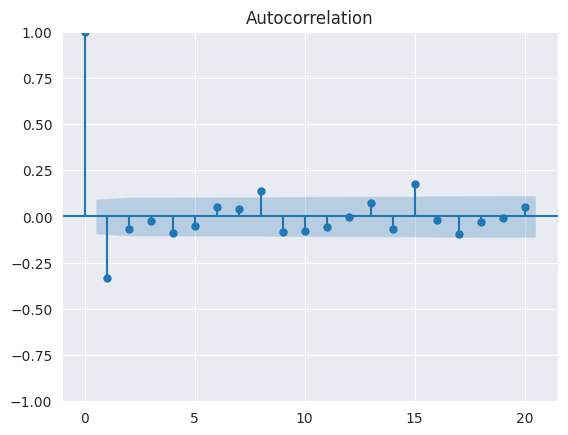

In [ ]:
# plot the autocorrelation function (ACF) to identify the MA
sns.set_style("darkgrid")
plot_acf(usep_diff, lags = 20)
plt.show()

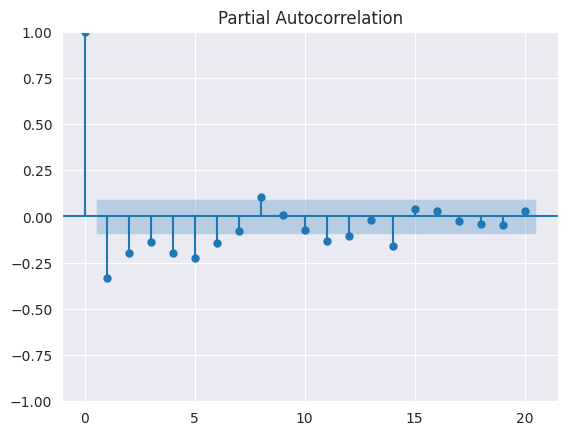

In [ ]:
# plot the partial autocorrelation function (PACF) to identify AR
plot_pacf(usep_diff, lags = 20)
plt.show()

In [ ]:
# initialize ARIMA model
arima_model = ARIMA(usep_df['USEP'], order = (1, 1, 1))
# fit the model parameters
arima_results = arima_model.fit()
# display the estimation summary
print(arima_results.summary())

                               SARIMAX Results                                
Dep. Variable:                   USEP   No. Observations:                  423
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2095.606
Date:                Tue, 26 May 2026   AIC                           4197.212
Time:                        03:01:45   BIC                           4209.347
Sample:                             0   HQIC                          4202.007
                                - 423                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3888      0.039     10.069      0.000       0.313       0.465
ma.L1         -0.9181      0.022    -42.190      0.000      -0.961      -0.875
sigma2      1201.3733     23.491     51.142      0.0

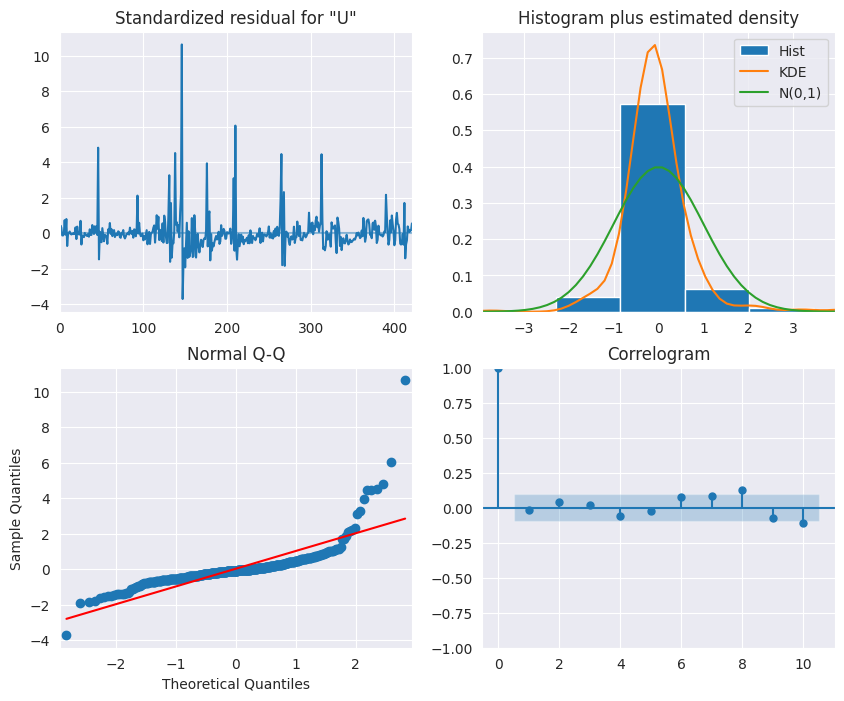

In [ ]:
# generate diagnostic plots for the fitted ARIMA model
arima_results.plot_diagnostics(figsize = (10, 8))
plt.show()

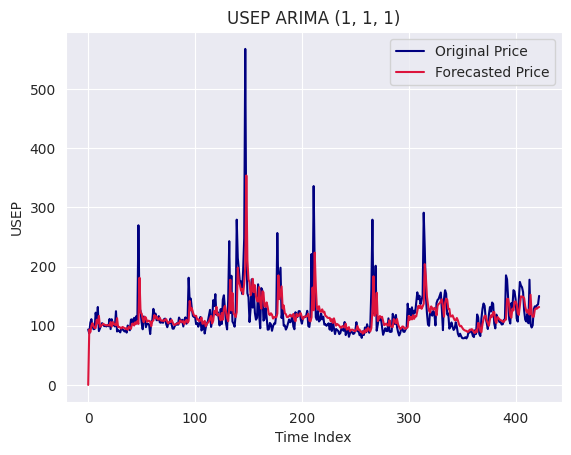

In [ ]:
# plot the actual USEP and the forecasted USEP based on ARIMA model
forecast = arima_results.predict(start = usep_df.index[0], end = usep_df.index[-1])
plt.plot(usep_df['USEP'], color = "navy", label = "Original Price")
plt.plot(forecast, color = "crimson", label = "Forecasted Price")
plt.title("USEP ARIMA (1, 1, 1)")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()

# **GARCH**

In [ ]:
# extract the raw residuals from the fitted ARIMA model
residuals = arima_results.resid

In [ ]:
# initialize the GARCH model to analyze the volatility
garch_model = arch_model(residuals, p = 1, q = 1, vol = "GARCH", dist = "t")
# fit the GARCH model parameters to the residuals
garch_results = garch_model.fit(disp = 0)
# print the parameter estimations
print(garch_results.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1857.75
Distribution:      Standardized Student's t   AIC:                           3725.51
Method:                  Maximum Likelihood   BIC:                           3745.74
                                              No. Observations:                  423
Date:                      Tue, May 26 2026   Df Residuals:                      422
Time:                              03:01:47   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -3

# **Feature Engineering**

In [ ]:
# create a new feature by shifting the ARIMA residuals backward by one time step
usep_df['lag1'] = usep_df['USEP'].shift(1)

In [ ]:
usep_df['arima_residuals_lag1'] = residuals.shift(1)

In [ ]:
# create a new feature by extracting the garch residuals
usep_df['garch_residual'] = garch_results.resid

In [ ]:
# create a new feature by calculating the standardized residuals from the GARCH model
usep_df['garch_std_resid'] = garch_results.resid/ garch_results.conditional_volatility

In [ ]:
# drop all rows containing missing values (NaNs)
usep_df = usep_df.dropna()
usep_df.head()

,DATE,USEP,DEMAND,SOLAR,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
1,2025-01-02,87.035833,6358.067917,162.426042,93.600833,93.600833,-2.975886,-0.037788
2,2025-01-03,105.036667,6407.756771,174.522083,87.035833,-6.519986,19.596264,0.387499
3,2025-01-04,111.137083,6158.840583,177.016875,105.036667,16.052163,14.834499,0.402655
4,2025-01-05,99.658542,5989.193917,176.524375,111.137083,11.290398,-1.259385,-0.044884
5,2025-01-06,94.180833,6446.642542,176.036458,99.658542,-4.803486,-1.453464,-0.070010


In [ ]:
# compute the pairwise pearson correlation coefficients for all numerical columns.
usep_df.corr(method = "spearman")

,DATE,USEP,DEMAND,SOLAR,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
DATE,1.000000,0.070640,0.103216,0.418540,0.069047,-0.024640,-0.012412,-0.040243
USEP,0.070640,1.000000,0.540707,0.028812,0.685872,0.328700,0.578880,0.611230
DEMAND,0.103216,0.540707,1.000000,-0.051947,0.405253,0.177026,0.223944,0.240115
SOLAR,0.418540,0.028812,-0.051947,1.000000,0.075969,0.007806,0.002070,-0.008009
lag1,0.069047,0.685872,0.405253,0.075969,1.000000,0.569461,0.017546,0.023949
arima_residuals_lag1,-0.024640,0.328700,0.177026,0.007806,0.569461,1.000000,0.211965,0.203074
garch_residual,-0.012412,0.578880,0.223944,0.002070,0.017546,0.211965,1.000000,0.968750
garch_std_resid,-0.040243,0.611230,0.240115,-0.008009,0.023949,0.203074,0.968750,1.000000


In [ ]:
# drop the irrelevant columns
usep_df = usep_df.drop(columns = ['DATE', 'DEMAND', 'SOLAR'])
usep_df.head()

,USEP,lag1,arima_residuals_lag1,garch_residual,garch_std_resid
1,87.035833,93.600833,93.600833,-2.975886,-0.037788
2,105.036667,87.035833,-6.519986,19.596264,0.387499
3,111.137083,105.036667,16.052163,14.834499,0.402655
4,99.658542,111.137083,11.290398,-1.259385,-0.044884
5,94.180833,99.658542,-4.803486,-1.453464,-0.070010


# **Data Splitting**

In [ ]:
# separate the features from the target
X = usep_df.drop(columns = ['USEP'])
y = usep_df['USEP']

In [ ]:
# split the features into training and testing sets
X_train, X_test = X.iloc[:366], X.iloc[366:]
y_train, y_test = y.iloc[:366], y.iloc[366:]

In [ ]:
X_train_reshaped = np.expand_dims(X_train, axis = 1)
X_test_reshaped = np.expand_dims(X_test, axis = 1)

# **Model Training**

In [ ]:
# time series split
tscv = TimeSeriesSplit(n_splits = 5)

In [ ]:
# hyperparameters tuning
dense_neurons_layer1 = [8, 16, 32]
dense_neurons_layer2 = [8, 16, 32]

best_rmse = float("inf")
best_params = None


for dense_neuron_layer1 in dense_neurons_layer1:
  for dense_neuron_layer2 in dense_neurons_layer2:
    rmses = []

    for train_idx, val_idx in tscv.split(X_train_reshaped):
      X_train_fold, X_val_fold = X_train_reshaped[train_idx], X_train_reshaped[val_idx]
      y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

      model = Sequential()
      model.add(Bidirectional(LSTM(128, kernel_regularizer = "l2", activation = "tanh", return_sequences = True), input_shape = (1, 4)))
      model.add(LSTM(32, kernel_regularizer = "l2", activation = "tanh"))
      model.add(Dense(dense_neuron_layer1, activation = "relu"))
      model.add(Dense(dense_neuron_layer2, activation = "relu"))
      model.add(Dense(1))
      model.compile(optimizer = "adam", loss = "mse", metrics = ['mse'])

      model.fit(X_train_fold, y_train_fold,
                epochs = 100,
                batch_size = 32,
                validation_split = 0.1,
                verbose = 1)

      y_pred_val = model.predict(X_val_fold)
      rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_val))
      rmses.append(rmse)

    avg_rmse = np.mean(rmses)

    print("dense_neuron_layer1 = {}, dense_neuron_layer2 = {}, RMSE = {:.4f}".format(dense_neuron_layer1, dense_neuron_layer2, avg_rmse))
    if avg_rmse < best_rmse:
      best_rmse = avg_rmse
      best_params = {'dense_neuron_layer1': dense_neuron_layer1,
                     'dense_neuron_layer2': dense_neuron_layer2}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 11785.8438 - mse: 11783.9824 - val_loss: 11270.2588 - val_mse: 11268.4355
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 11780.7891 - mse: 11778.9756 - val_loss: 11265.5371 - val_mse: 11263.7598
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 11775.5176 - mse: 11773.7490 - val_loss: 11259.8213 - val_mse: 11258.0869
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 11769.2725 - mse: 11767.5449 - val_loss: 11253.0322 - val_mse: 11251.3369
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 11761.9648 - mse: 11760.2773 - val_loss: 11245.0732 - val_mse: 11243.4170
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 11753.6445 - mse: 11751.9951 - val_loss: 11235.9287 - val_mse: 11234.3057
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 11744.1250 - mse: 11742.5078 - val_loss: 11225.5400 - val_mse: 11223.9482
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 11733.3545 - mse: 11

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step - loss: 11934.4404 - mse: 11932.6074 - val_loss: 14346.0000 - val_mse: 14344.2246
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 11897.5088 - mse: 11895.7578 - val_loss: 14299.3770 - val_mse: 14297.6777
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 11853.5811 - mse: 11851.9033 - val_loss: 14244.2803 - val_mse: 14242.6475
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 11803.0225 - mse: 11801.4092 - val_loss: 14182.3613 - val_mse: 14180.7832
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11746.6172 - mse: 11745.0547 - val_loss: 14115.5010 - val_mse: 14113.9707
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 11685.5078 - mse: 11683.9883 - val_loss: 14045.0361 - val_mse: 14043.5410
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11621.2412 - mse: 11619.7549 - val_loss: 13973.4385 - val_mse: 13971.9707
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 11556.2520 - mse: 11554.7900 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 17086.5586 - mse: 17084.7285 - val_loss: 17690.4121 - val_mse: 17688.6758
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 17032.4727 - mse: 17030.7793 - val_loss: 17620.0039 - val_mse: 17618.3809
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16953.0176 - mse: 16951.4277 - val_loss: 17513.1270 - val_mse: 17511.5996
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16830.2969 - mse: 16828.7969 - val_loss: 17342.4629 - val_mse: 17341.0078
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 16639.3047 - mse: 16637.8672 - val_loss: 17083.9082 - val_mse: 17082.5000
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 16357.6006 - mse: 16356.2031 - val_loss: 16720.2695 - val_mse: 16718.8848
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15971.3213 - mse: 15969.9355 - val_loss: 16237.5430 - val_mse: 16236.1543
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15470.9736 - mse: 15469.5791 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 17083.1699 - mse: 17081.3652 - val_loss: 9137.7559 - val_mse: 9136.0273
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 16929.1875 - mse: 16927.5078 - val_loss: 8970.6992 - val_mse: 8969.0791
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 16690.9785 - mse: 16689.3945 - val_loss: 8737.2773 - val_mse: 8735.7354
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 16352.9707 - mse: 16351.4512 - val_loss: 8415.7617 - val_mse: 8414.2666
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15888.2451 - mse: 15886.7588 - val_loss: 8004.1533 - val_mse: 8002.6719
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15305.1807 - mse: 15303.6943 - val_loss: 7513.1069 - val_mse: 7511.6099
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 14614.2686 - mse: 14612.7559 - val_loss: 6953.4717 - val_mse: 6951.9351
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 13843.0215 - mse: 13841.4639 - val_loss: 634

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 15960.6299 - mse: 15958.8486 - val_loss: 10682.3730 - val_mse: 10680.6904
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 15826.7939 - mse: 15825.1680 - val_loss: 10517.3457 - val_mse: 10515.7881
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 15590.2266 - mse: 15588.7061 - val_loss: 10245.8213 - val_mse: 10244.3408
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 15209.7100 - mse: 15208.2441 - val_loss: 9837.5869 - val_mse: 9836.1309
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 14659.3105 - mse: 14657.8467 - val_loss: 9269.5518 - val_mse: 9268.0703
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 13905.4473 - mse: 13903.9453 - val_loss: 8538.4014 - val_mse: 8536.8613
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 12987.3594 - mse: 12985.7900 - val_loss: 7678.7378 - val_mse: 7677.1250
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 11907.1328 - mse: 11905.4883 - val_los

In [ ]:
print("Best Parameters: \n")
print(best_params)

print("Best RMSE: \n")
print(best_rmse)

Best Parameters: 

{'dense_neuron_layer1': 32, 'dense_neuron_layer2': 32}
Best RMSE: 

21.80629527366256


In [ ]:
op_model = Sequential()
op_model.add(Bidirectional(LSTM(128,
                                kernel_regularizer = "l2",
                                activation = "tanh",
                                return_sequences = True),
                           input_shape = (1, 4)))
op_model.add(LSTM(32, kernel_regularizer = "l2", activation = "tanh"))
op_model.add(Dense(32, activation = "relu"))
op_model.add(Dense(32, activation = "relu"))
op_model.add(Dense(1))
op_model.compile(optimizer = "adam", loss = "mse", metrics = ['mse'])

op_model.summary()

history = op_model.fit(X_train_reshaped, y_train,
                    epochs = 100,
                    validation_split = 0.1,
                    batch_size = 32,
                    verbose = 1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_130"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_129               │ (None, 1, 256)         │       136,192 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_259 (LSTM)                 │ (None, 32)             │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_386 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_387 (Dense)               │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_388 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,329 (684.88 KB)

 Trainable params: 175,329 (684.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 15927.4746 - mse: 15925.7266 - val_loss: 10495.2920 - val_mse: 10493.6719
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 15853.2021 - mse: 15851.6582 - val_loss: 10394.2979 - val_mse: 10392.8447
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 15691.6045 - mse: 15690.1992 - val_loss: 10183.4561 - val_mse: 10182.0947
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15376.0381 - mse: 15374.6904 - val_loss: 9827.7891 - val_mse: 9826.4434
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 14875.1123 - mse: 14873.7480 - val_loss: 9322.6973 - val_mse: 9321.2979
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 14190.7432 - mse: 14189.3066 - val_loss: 8657.8340 - val_mse: 8656.3438
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 13295.0850 - mse: 13293.5547 - val_loss: 7827.3232 - val_mse: 7825.7397
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 12222.8701

# **Model Evaluation**

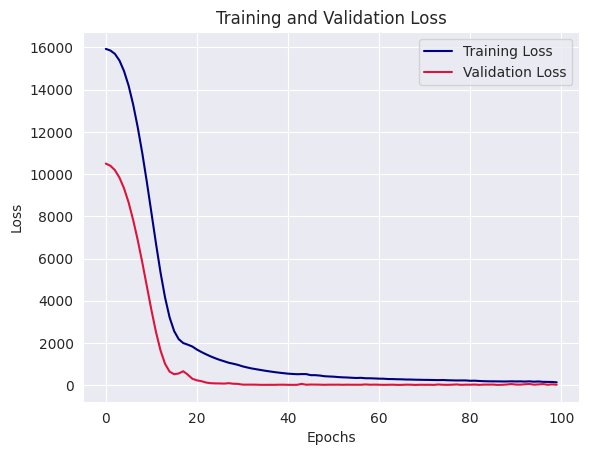

In [ ]:
plt.plot(history.history['loss'], label = 'Training Loss', color = "navy")
plt.plot(history.history['val_loss'], label = 'Validation Loss', color = "crimson")
plt.title("Training and Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

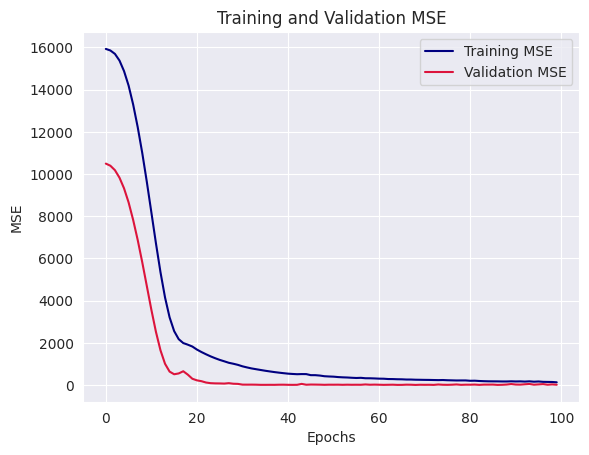

In [ ]:
plt.plot(history.history['mse'], label = 'Training MSE', color = "navy")
plt.plot(history.history['val_mse'], label = 'Validation MSE', color = "crimson")
plt.title("Training and Validation MSE")
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [ ]:
# use the optimized refitted random forest model to predict the price for the training set and testing set
y_pred_train = op_model.predict(X_train_reshaped)
y_pred_test = op_model.predict(X_test_reshaped)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [ ]:
# compute the evaluation for the training set
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

In [ ]:
# compute the evaluation for the testing set
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

In [ ]:
# display the evaluation results for the training set
print("Mean Absolute Error (MAE): {:.4f}".format(mae_train))
print("Root Mean Squared Error (MSE): {:.4f}".format(np.sqrt(mse_train)))
print("R-squared (R2) Score: {:.4f}".format(r2_train))

Mean Absolute Error (MAE): 3.6843
Root Mean Squared Error (MSE): 10.7931
R-squared (R2) Score: 0.9348


In [ ]:
# display the evaluation results for the testing set
print("Mean Absolute Error (MAE): {:.4f}".format(mae_test))
print("Root Mean Squared Error (MSE): {:.4f}".format(np.sqrt(mse_test)))
print("R-squared (R2) Score: {:.4f}".format(r2_test))

Mean Absolute Error (MAE): 5.0070
Root Mean Squared Error (MSE): 7.1711
R-squared (R2) Score: 0.9121


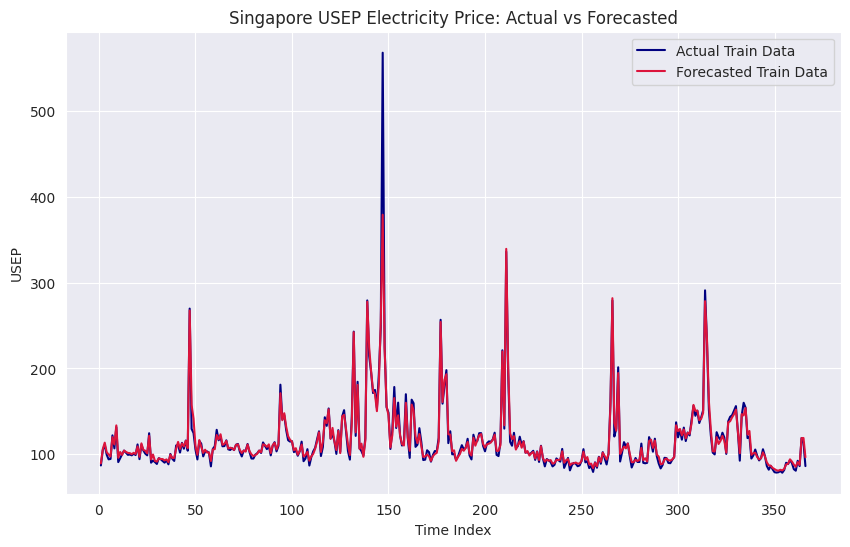

In [ ]:
# convert the raw training numpy array predictions into a pandas Series
y_pred_train_series = pd.Series(y_pred_train.flatten(), index = y_train.index)

# plot the actual vs forecasted USEP electricity price based on training set
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.plot(y_train.index,
         y_train.values, color = "navy", label = "Actual Train Data")
plt.plot(y_pred_train_series.index,
         y_pred_train_series.values, color = "crimson", label = "Forecasted Train Data")
plt.title("Singapore USEP Electricity Price: Actual vs Forecasted")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()

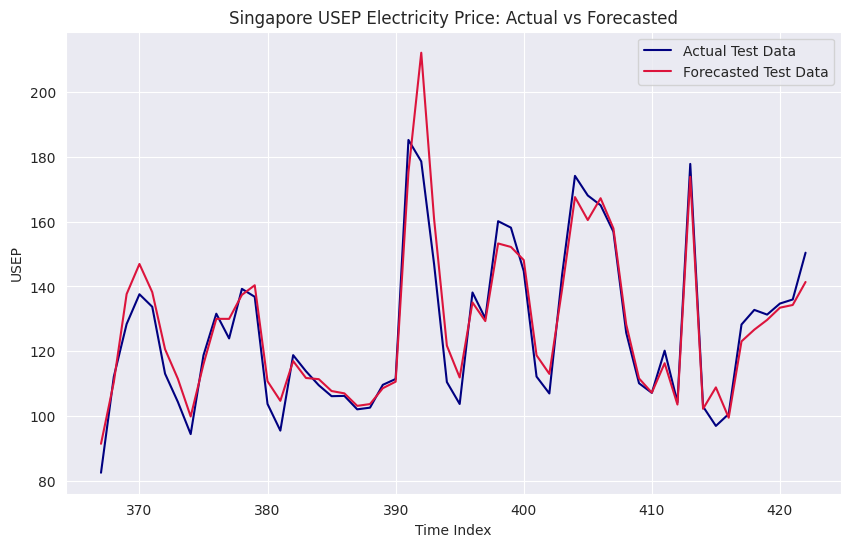

In [ ]:
# convert the raw testing numpy array predictions into a pandas Series
y_pred_test_series = pd.Series(y_pred_test.flatten(), index = y_test.index)

# plot the actual vs forecasted USEP electricity price based on testing set
plt.figure(figsize = (10, 6))
sns.set_style("darkgrid")
plt.plot(y_test.index,
         y_test.values, color = "navy", label = "Actual Test Data")
plt.plot(y_pred_test_series.index,
         y_pred_test_series.values, color = "crimson", label = "Forecasted Test Data")
plt.title("Singapore USEP Electricity Price: Actual vs Forecasted")
plt.xlabel("Time Index")
plt.ylabel("USEP")
plt.legend()
plt.show()